In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import glob
import os
import yaml
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import torch
import numpy as np
import matplotlib.pyplot as plt
drive.mount('/content/drive')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive


In [ ]:
# 1. 압축 해제
zip_path = '/content/drive/MyDrive/tuk_YOLO_data/tuk_objects_completed2.zip'
extract_dir = '/content/dataset/'

!unzip -qo "{zip_path}" -d "{extract_dir}"
print("✅ 압축 해제가 완료되었습니다!")

✅ 압축 해제가 완료되었습니다!


📸 욜로 포맷 경로에서 총 34937장의 원본 이미지를 정상적으로 찾았습니다!
✂️ 10프레임 간격 스킵 적용: 3494장이 추출되었습니다.
📊 최종 데이터 분할 완료:
   - Train (학습용)    : 2795장
   - Val   (검증용)    : 349장
   - Test  (최종평가용): 350장

📊 클래스별 분포
elevator           Train: 79.4% Val:  8.4% Test: 12.3% (총 383)
vending_machine    Train: 80.6% Val: 10.0% Test:  9.4% (총 350)
trash_bin          Train: 80.0% Val:  9.1% Test: 10.9% (총 440)
self_service_cafe  Train: 79.6% Val:  8.6% Test: 11.8% (총 152)
water_dispenser    Train: 80.2% Val:  9.7% Test: 10.1% (총 227)
locker             Train: 78.8% Val:  9.8% Test: 11.4% (총 193)
door               Train: 80.3% Val:  9.4% Test: 10.3% (총 959)
obstacle           Train: 82.1% Val:  9.9% Test:  8.0% (총 262)
photo_copier       Train: 78.6% Val: 10.7% Test: 10.7% (총 112)
person             Train: 77.0% Val: 12.6% Test: 10.4% (총 613)
lectern            Train: 82.8% Val:  8.9% Test:  8.3% (총 325)
desk               Train: 84.2% Val:  8.3% Test:  7.6% (총 1912)
chair              Train: 82.9% Val:  9.4% Test:  7.7% (총

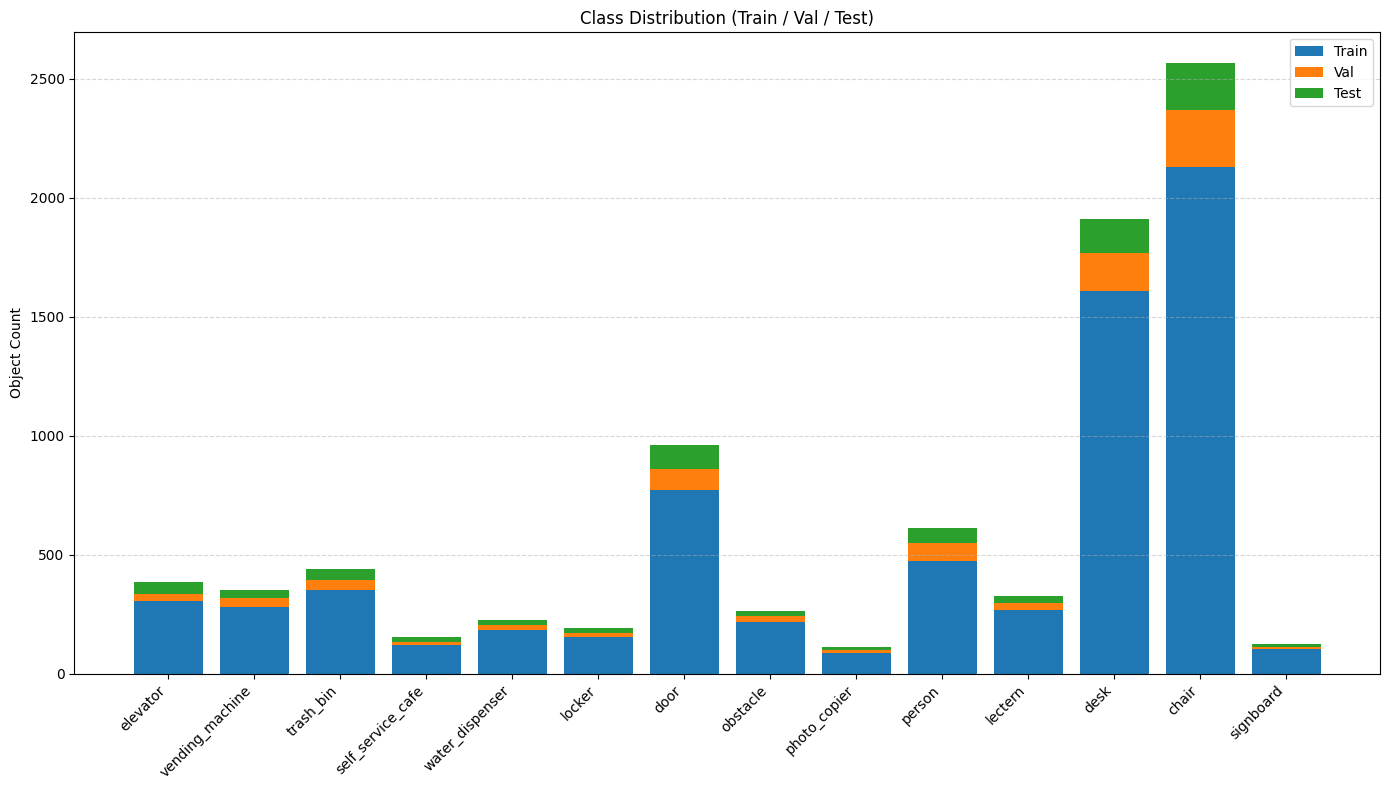

✅ data.yaml 파일이 생성되었습니다.
🚀 학습 디바이스 설정 완료: 0
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer

In [ ]:
# 2. 이미지 파일 목록 가져오기 (YOLO 포맷 표준 경로 체크)
image_dir = '/content/dataset/train/images/'
image_files = sorted(glob.glob(os.path.join(image_dir, '*.png')))

# 1순위 경로에 없으면 2순위 경로 자동 탐색
if len(image_files) == 0:
    image_dir = '/content/dataset/images/train/'
    image_files = sorted(glob.glob(os.path.join(image_dir, '*.png')))

# 최종 경로 확인 및 처리
if len(image_files) == 0:
    print(f"❌ 여전히 이미지를 찾지 못했습니다. 현재 dataset 내부 구조를 확인하세요:")
    if os.path.exists('/content/dataset/'):
        print(os.listdir('/content/dataset/'))
    else:
        print("dataset 폴더가 존재하지 않습니다.")

else:

    print(f"📸 욜로 포맷 경로에서 총 {len(image_files)}장의 원본 이미지를 정상적으로 찾았습니다!")

    # [1단계] 원본 데이터 중 10프레임당 1장씩 추출
    selected_images = image_files[::10]
    print(f"✂️ 10프레임 간격 스킵 적용: {len(selected_images)}장이 추출되었습니다.")

    # [2단계] 8:1:1 분할
    train_imgs, temp_imgs = train_test_split(
        selected_images,
        test_size=0.2,
        random_state=42
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.5,
        random_state=42
    )

    # txt 파일 저장 함수
    def save_txt(path, img_list):
        with open(path, 'w') as f:
            for img_path in img_list:
                f.write(os.path.abspath(img_path) + '\n')

    save_txt('/content/dataset/train.txt', train_imgs)
    save_txt('/content/dataset/val.txt', val_imgs)
    save_txt('/content/dataset/test.txt', test_imgs)

    print(f"📊 최종 데이터 분할 완료:")
    print(f"   - Train (학습용)    : {len(train_imgs)}장")
    print(f"   - Val   (검증용)    : {len(val_imgs)}장")
    print(f"   - Test  (최종평가용): {len(test_imgs)}장")

    # 클래스 분포 확인
    class_names = [
        'elevator', 'vending_machine', 'trash_bin', 'self_service_cafe',
        'water_dispenser', 'locker', 'door', 'obstacle', 'photo_copier',
        'person', 'lectern', 'desk', 'chair', 'signboard'
    ]

    nc = len(class_names)
    def count_classes(img_list):
        counts = [0] * nc
        for img_path in img_list:
            label_path = img_path.replace(
                '/images/',
                '/labels/'
            ).replace('.png', '.txt')
            if not os.path.exists(label_path):
                continue
            with open(label_path, 'r') as f:
                for line in f:
                    if line.strip():
                        cls = int(line.split()[0])
                        counts[cls] += 1
        return counts

    train_counts = count_classes(train_imgs)
    val_counts = count_classes(val_imgs)
    test_counts = count_classes(test_imgs)

    print("\n📊 클래스별 분포")

    for i, name in enumerate(class_names):
        total = (
            train_counts[i]
            + val_counts[i]
            + test_counts[i]
        )
        if total == 0:
            continue

        print(
            f"{name:18s} "
            f"Train:{train_counts[i]/total*100:5.1f}% "
            f"Val:{val_counts[i]/total*100:5.1f}% "
            f"Test:{test_counts[i]/total*100:5.1f}% "
            f"(총 {total})"
        )

    # 객체 개수 그래프
    x = np.arange(nc)

    plt.figure(figsize=(14, 8))

    plt.bar(x, train_counts, label='Train')
    plt.bar(x, val_counts, bottom=train_counts, label='Val')
    plt.bar(
        x,
        test_counts,
        bottom=np.array(train_counts) + np.array(val_counts),
        label='Test'
    )

    plt.xticks(x, class_names, rotation=45, ha='right')
    plt.ylabel('Object Count')
    plt.title('Class Distribution (Train / Val / Test)')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # data.yaml 생성
    data_config = {
        'train': '/content/dataset/train.txt',
        'val': '/content/dataset/val.txt',
        'test': '/content/dataset/test.txt',
        'nc': 14,
        'names': class_names
    }

    with open('/content/dataset/data.yaml', 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False)

    print("✅ data.yaml 파일이 생성되었습니다.")

    # 학습 시작
    selected_device = 0 if torch.cuda.is_available() else 'cpu'
    print(f"🚀 학습 디바이스 설정 완료: {selected_device}")

    model = YOLO('yolov8n.pt')

    model.train(
        data='/content/dataset/data.yaml',
        epochs=100,
        imgsz=640,
        patience=20,
        device=selected_device
    )